In [56]:
# import libraries
import yfinance as yf
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score


In [57]:
df=yf.download("AAPL", start= "2018-01-01", end="2025-01-01")

[*********************100%***********************]  1 of 1 completed


In [58]:
print(df.head())

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2018-01-02  40.304165  40.313526  39.602246  39.812824  102223600
2018-01-03  40.297157  40.839976  40.233987  40.367350  118071600
2018-01-04  40.484337  40.587286  40.262063  40.369689   89738400
2018-01-05  40.945248  41.031816  40.489001  40.580251   94640000
2018-01-08  40.793182  41.087987  40.694911  40.793182   82271200


In [59]:
df.reset_index(inplace=True)
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2018-01-02,40.304165,40.313526,39.602246,39.812824,102223600
1,2018-01-03,40.297157,40.839976,40.233987,40.367350,118071600
2,2018-01-04,40.484337,40.587286,40.262063,40.369689,89738400
3,2018-01-05,40.945248,41.031816,40.489001,40.580251,94640000
4,2018-01-08,40.793182,41.087987,40.694911,40.793182,82271200


In [60]:
print("Dataset Shape: ", df.shape)

Dataset Shape:  (1761, 6)


In [61]:
df['MA20']=df['Close'].rolling(20).mean()
df['MA50']=df['Close'].rolling(50).mean()

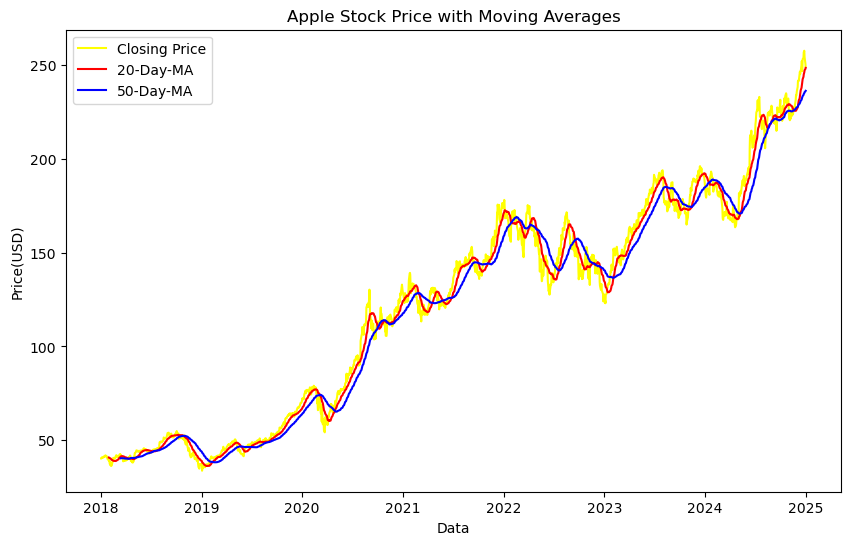

In [62]:
plt.figure(figsize=(10,6))
plt.plot(df['Date'],df['Close'], label='Closing Price', color='yellow')
plt.plot(df['Date'], df['MA20'], label='20-Day-MA', color='red')
plt.plot(df['Date'],df['MA50'], label='50-Day-MA', color='blue')
plt.title("Apple Stock Price with Moving Averages")
plt.xlabel("Data")
plt.ylabel("Price(USD)")
plt.legend()
plt.show()

In [63]:
# Target: Next day's closing price
df['Target']=df['Close'].shift(-1)
# Drop missing value
df.dropna(inplace=True)
print("Cleaned Dataset Shape:", df.shape)
print(df.head())

Cleaned Dataset Shape: (1711, 9)
Price        Date      Close       High        Low       Open     Volume  \
Ticker                  AAPL       AAPL       AAPL       AAPL       AAPL   
49     2018-03-14  41.920349  42.408997  41.772344  42.362013  117473600   
50     2018-03-15  41.969692  42.343229  41.833438  41.934455   90975200   
51     2018-03-16  41.821671  42.080088  41.727698  41.969672  157618800   
52     2018-03-19  41.182671  41.692461  40.797391  41.657224  133787200   
53     2018-03-20  41.168587  41.535072  41.098108  41.168587   78597600   

Price        MA20       MA50     Target  
Ticker                                   
49      41.299791  40.394659  41.969692  
50      41.432290  40.427970  41.821671  
51      41.491374  40.458460  41.182671  
52      41.525085  40.472427  41.168587  
53      41.564905  40.476894  40.235924  


In [64]:
# select Features input columns
features=['Open', "High", 'Low', 'Volume','MA20','MA50']
X=df[features]
y=df['Target']
# split data into training and testing phase
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)
print("Training Size ", X_train.shape)
print("Testing Size", y_train.shape)



Training Size  (1368, 6)
Testing Size (1368,)


In [83]:
lr_model=LinearRegression()
lr_model.fit(X_train,y_train)
# prediction
lr_pred=lr_model.predict(X_test)
# Evaluate 
lr_mae=mean_absolute_error(y_test,lr_pred)
lr_r2=r2_score(y_test,lr_pred)
print("-------LinearRegressionModel______")
print(f"Mean Absolute Error: {lr_mae:.2f}")
print(f"r2 Score:  {lr_r2}")

-------LinearRegressionModel______
Mean Absolute Error: 1.70
r2 Score:  0.9982072598474714


In [85]:
rf_model=RandomForestRegressor(n_estimators=100 , random_state=42)
rf_model.fit(X_train,y_train)
# Prediction
rf_pred=rf_model.predict(X_test)
# Evaluation
rf_mae=mean_absolute_error(y_test,rf_pred)
rf_r2=r2_score(y_test,rf_pred)
print("----------RandomForestRegressor--------------")
print(f"Mean Absolute Error:  {rf_mae}")
print(f"r2 Score:  {rf_r2}")

----------RandomForestRegressor--------------
Mean Absolute Error:  1.7756685896448068
r2 Score:  0.9981738952170289


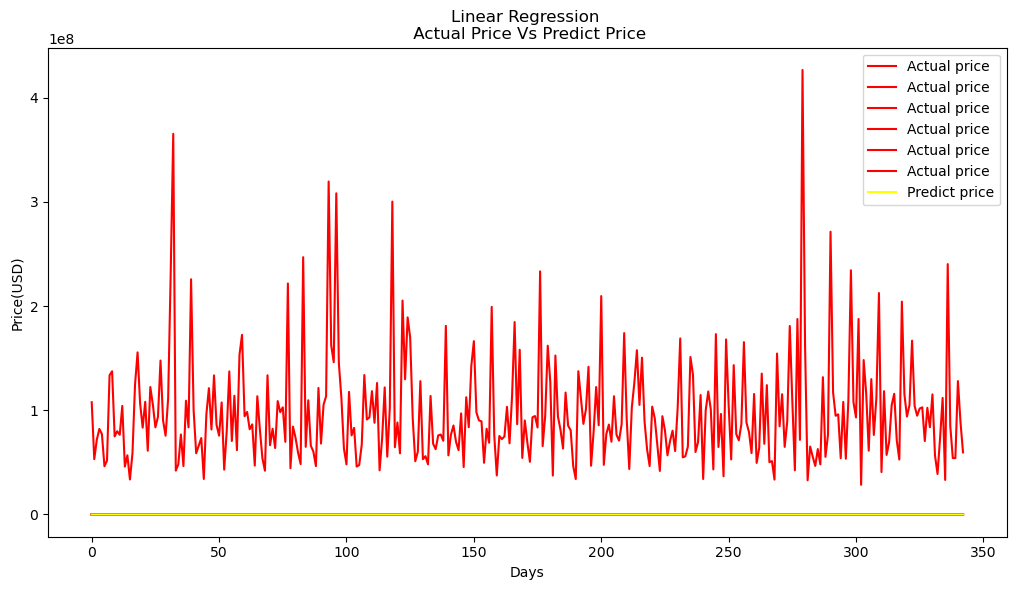

In [93]:
plt.figure(figsize=(20,6))
plt.subplot(1,2,2)
plt.plot(X_test.values, label='Actual price', color='red')
plt.plot(lr_pred, label='Predict price', color='yellow')
plt.title("Linear Regression \n Actual Price Vs Predict Price")
plt.xlabel("Days")
plt.ylabel("Price(USD)")
plt.legend()
plt.tight_layout()
plt.show()

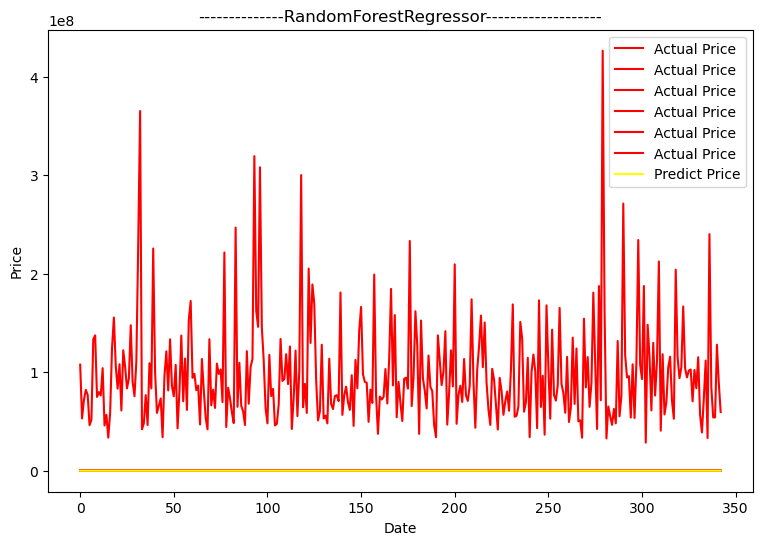

In [94]:
plt.figure(figsize=(20,6))
plt.subplot(1,2,2)
plt.plot(X_test.values, label="Actual Price", color='red')
plt.plot(rf_pred, label='Predict Price', color='yellow')
plt.title("--------------RandomForestRegressor-------------------")
plt.xlabel("Date")
plt.ylabel('Price')
plt.legend()
plt.show()